# Feature Engineering on CIC-IDS 2018 Dataset
Balanced reduction of redundant or unused features.

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and clean data (isolated for FE dependency)
df1 = pd.read_csv('../../data/raw/03-02-2018.csv', low_memory=False)
df2 = pd.read_csv('../../data/raw/02-16-2018.csv', low_memory=False)
df1_sampled = df1.sample(n=100000, random_state=42)
df2_sampled = df2.sample(n=100000, random_state=42)
df = pd.concat([df1_sampled, df2_sampled], ignore_index=True)
cols_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
feature_cols = df.columns.drop(['Label'], errors='ignore')
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df['Label'] = df['Label'].astype(str).str.lower().str.strip()
df['BinaryLabel'] = (df['Label'] != 'benign').astype(int)
df['AttackType'] = df['Label']

In [3]:
# Verify data
print('Shape before FE:', df.shape)
print('Number of columns before FE:', len(df.columns))

Shape before FE: (199607, 81)
Number of columns before FE: 81


In [4]:
# Remove constant features
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
df.drop(columns=constant_cols, inplace=True)
print(f'Removed {len(constant_cols)} constant features: {constant_cols}')

Removed 10 constant features: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


In [5]:
# Compute correlation matrix
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'BinaryLabel' in num_cols:
    num_cols.remove('BinaryLabel')

corr_matrix = df[num_cols].corr().abs()

In [6]:
# Drop highly redundant features
def select_to_drop(f1, f2):
    f1_l, f2_l = f1.lower(), f2.lower()
    if 'subflow' in f1_l and 'total' not in f1_l: return f1
    if 'subflow' in f2_l and 'total' not in f2_l: return f2
    if 'mean' in f1_l and any(x in f2_l for x in ['max', 'min', 'std']): return f2
    if 'mean' in f2_l and any(x in f1_l for x in ['max', 'min', 'std']): return f1
    return f2

features_to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.98:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            if col1 not in features_to_drop and col2 not in features_to_drop:
                features_to_drop.add(select_to_drop(col1, col2))

df.drop(columns=list(features_to_drop), inplace=True, errors='ignore')
print(f'Dropped {len(features_to_drop)} highly redundant features.')

Dropped 19 highly redundant features.


In [7]:
# Final check
print('Final Shape:', df.shape)
print('Final Number of Features:', len(df.columns))
if 40 <= len(df.columns) <= 60:
    print('Feature count is within the optimal range (40-60).')
else:
    print('Notice: Feature count is outside the target 40-60 range.')

Final Shape: (199607, 52)
Final Number of Features: 52
Feature count is within the optimal range (40-60).


## Visualizing Clean Features
Plotting final distributions and correlation heatmap after engineering.

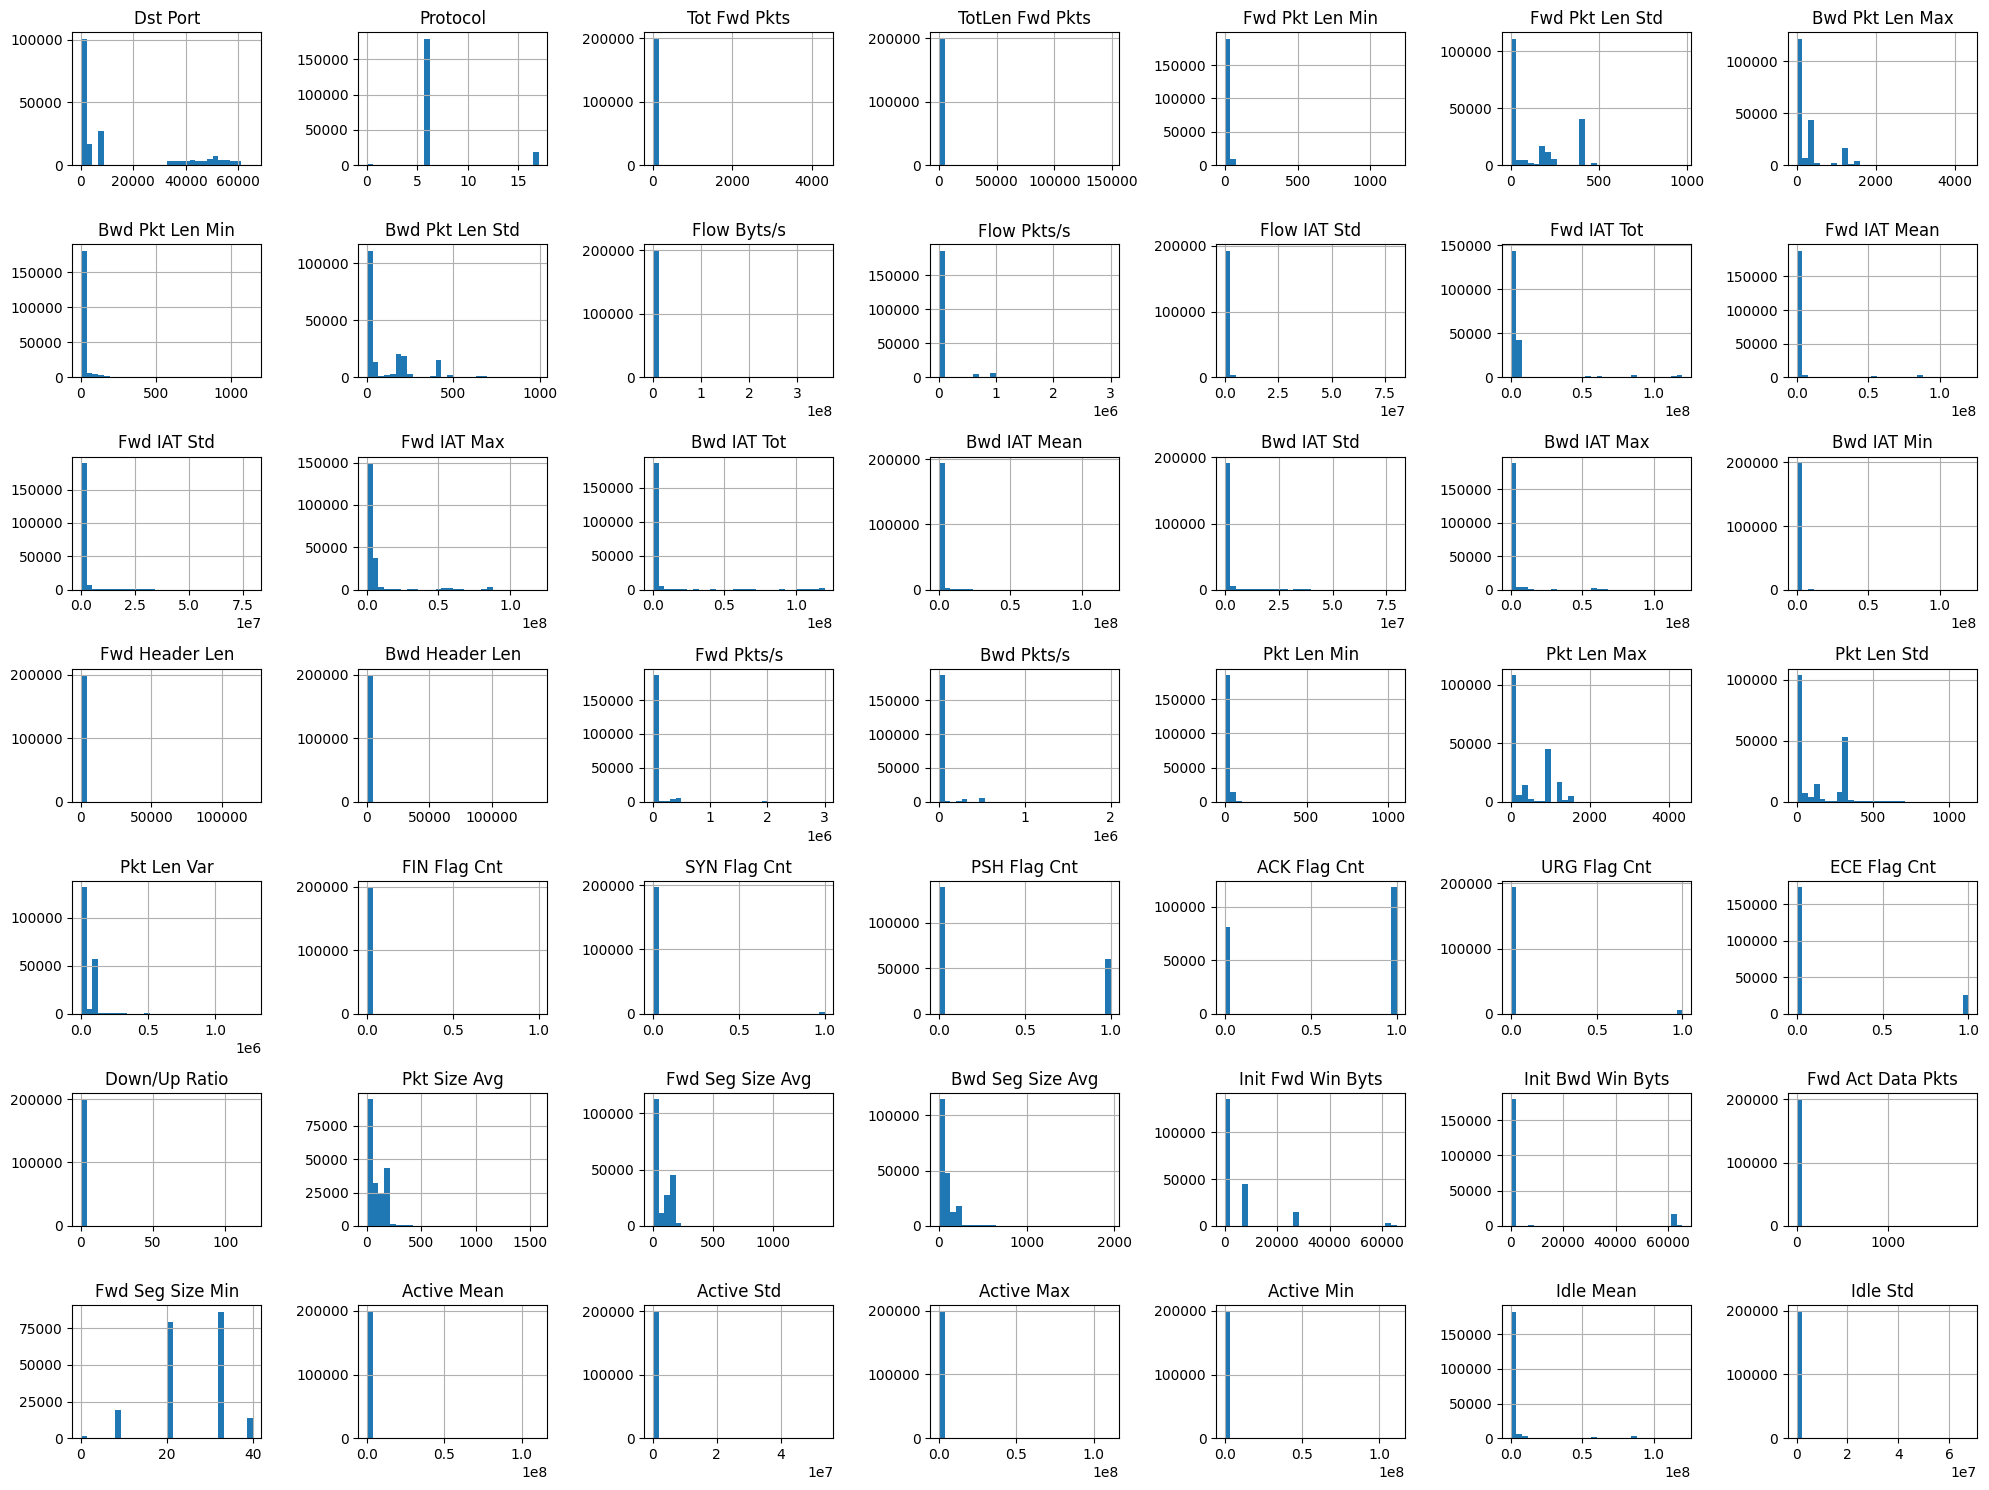

In [8]:
# Plot distributions of clean features
import os
output_dir = '../../outputs/plots/feature_engineering'
os.makedirs(output_dir, exist_ok=True)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'BinaryLabel' in num_cols:
    num_cols.remove('BinaryLabel')

df[num_cols].hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.savefig(f'{output_dir}/clean_feature_histograms.png')
plt.show()

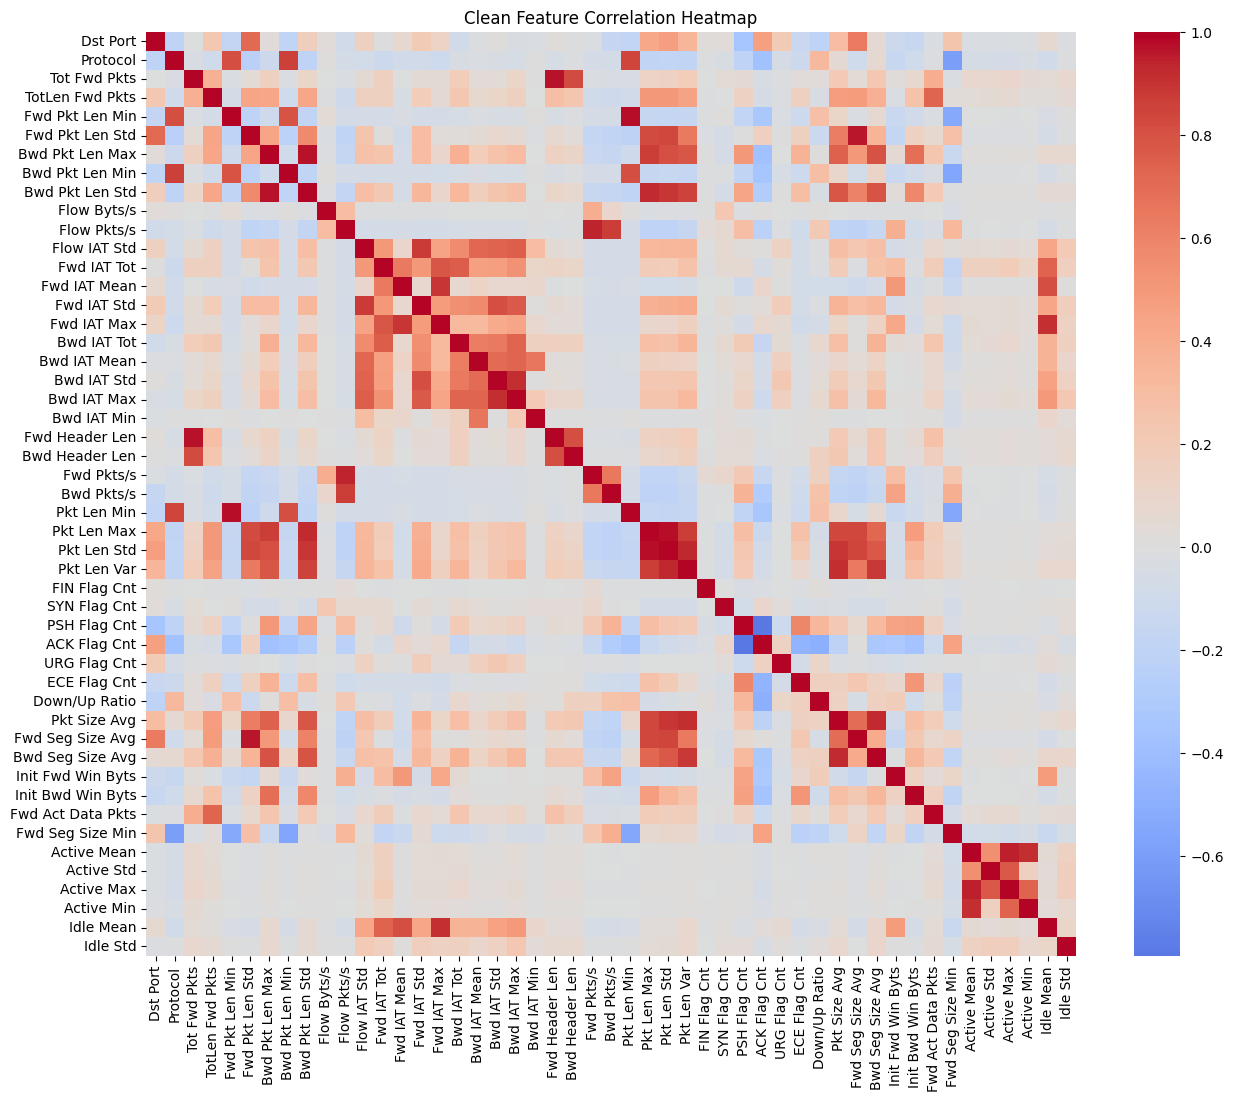

In [9]:
# Plot new correlation heatmap
plt.figure(figsize=(15, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Clean Feature Correlation Heatmap')
plt.savefig(f'{output_dir}/clean_correlation_heatmap.png')
plt.show()

In [10]:
# Save processed dataset
output_dir = '../../data/processed'
os.makedirs(output_dir, exist_ok=True)
df.to_csv(f'{output_dir}/clean_features.csv', index=False)
print('Processed dataset saved successfully to data/processed/clean_features.csv')

Processed dataset saved successfully to data/processed/clean_features.csv
